# 06 — PCA & Dimensionality Reduction: Visualizing High-Dimensional Clusters

**CustomerIQ — Customer Intelligence & Churn Prediction Platform**

---

## Objectives

In Phase 5, K-Means partitioned our customers across **46 dimensions**. Because humans cannot visualize a 46-dimensional space, we use **Principal Component Analysis (PCA)** to:

1. **Dimensionality Reduction Fundamentals**: Understand orthogonal projection, covariance matrices, and eigenvectors.
2. **Explained Variance & Scree Plots**: Quantify how much information each component preserves.
3. **2D Customer Cluster Map**: Project our 4 K-Means customer personas onto a 2D plane (PC1 vs PC2).
4. **2D Churn Risk Landscape**: Overlay actual churners on the 2D projection to see where flight risk concentrates.
5. **Feature Loadings (Biplot Analysis)**: Interpret the physical business meaning of PC1 and PC2.
6. **Model Serialization**: Save the fitted PCA transformer to `models/pca_2d.joblib`.

## 1. Setup & Environment

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.decomposition import PCA

# Add project root to sys.path
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import DATA_PROCESSED, MODELS_DIR, FIGURES_DIR, RANDOM_STATE
from src.visualization.pca_plots import fit_pca_projection, plot_explained_variance, plot_2d_pca_scatter

print("PCA environment initialized.")

PCA environment initialized.


---
## 2. Load Processed Features & Discovered Clusters

In [2]:
# Load 46-dimensional standardized feature matrix
X_proc = pd.read_csv(DATA_PROCESSED / 'X_train_processed.csv')

# Load the segmented customer dataset from Phase 5
df_segmented = pd.read_csv(DATA_PROCESSED / 'customer_segments.csv')
cluster_labels = df_segmented['Cluster'].values
churn_labels = df_segmented['Churn'].values

print(f"High-dimensional input shape: {X_proc.shape[0]} customers × {X_proc.shape[1]} features")
print(f"Cluster labels shape: {cluster_labels.shape}")
print(f"Churn labels shape: {churn_labels.shape}")

High-dimensional input shape: 5634 customers × 46 features
Cluster labels shape: (5634,)
Churn labels shape: (5634,)


---
## 3. Theory: How PCA Works Mathematically

PCA is an **unsupervised linear transformation** that finds the directions of maximum variance in high-dimensional data.

### Step 1: Mean Centering
Features must be centered at $\mu = 0$ (handled in Phase 2 by `StandardScaler`).

### Step 2: Covariance Matrix
Computes pairwise covariance across all 46 features:
$$\Sigma = \frac{1}{N} X^T X \quad \in \mathbb{R}^{46 \times 46}$$

### Step 3: Eigendecomposition (or SVD)
We solve for eigenvalues $\lambda$ and eigenvectors $v$:
$$\Sigma v_k = \lambda_k v_k$$
- **Eigenvectors ($v_k$)**: Define the orthogonal **directions** (principal axes) along which the data varies most.
- **Eigenvalues ($\lambda_k$)**: Measure the **amount of variance** captured along axis $v_k$.

### Step 4: Projection into Lower Dimension
To project from 46D down to 2D, we form a projection matrix $W = [v_1, v_2] \in \mathbb{R}^{46 \times 2}$ and compute:
$$Z = X W \quad \in \mathbb{R}^{N \times 2}$$
Each customer is now represented by two coordinates: $(PC1, PC2)$.

---
## 4. Explained Variance & Scree Analysis

How much information do we lose by compressing 46 dimensions down to 2?

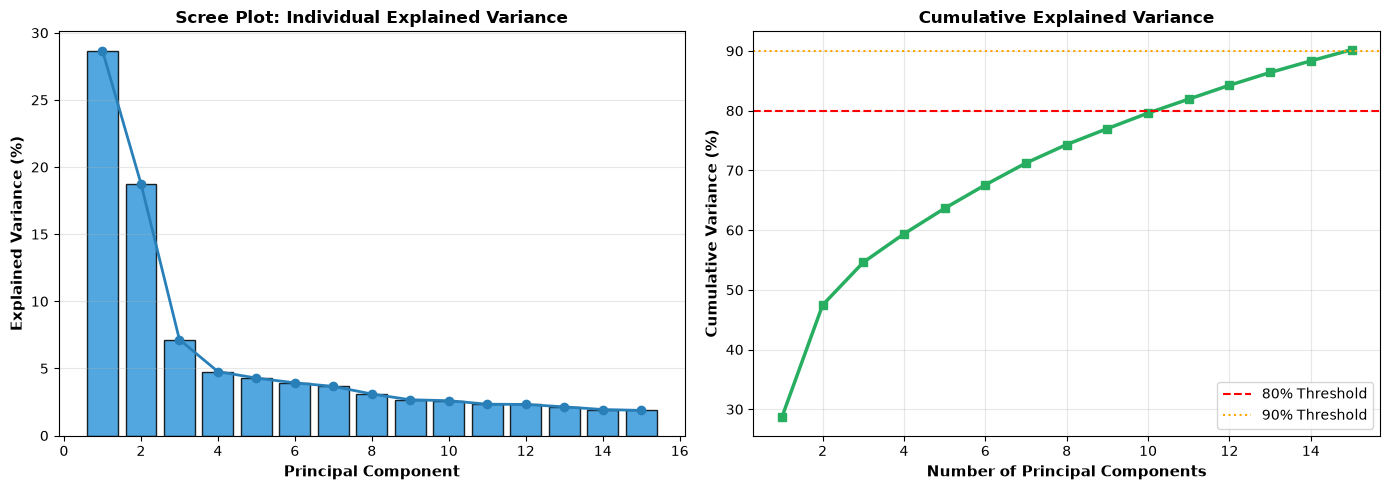

PC1 explains: 28.68% of total variance
PC2 explains: 18.77% of total variance
Combined 2D projection preserves: 47.45% of total variance

Scree plot saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\pca_scree_plot.png


In [3]:
# Fit PCA across 15 components to inspect variance decay
pca_full = PCA(n_components=15, random_state=RANDOM_STATE)
pca_full.fit(X_proc)

# Plot Scree and Cumulative variance
scree_fig_path = str(FIGURES_DIR / 'pca_scree_plot.png')
fig, (ax1, ax2) = plot_explained_variance(pca_full, save_path=scree_fig_path)
plt.show()

var_pc1 = pca_full.explained_variance_ratio_[0] * 100
var_pc2 = pca_full.explained_variance_ratio_[1] * 100
print(f"PC1 explains: {var_pc1:.2f}% of total variance")
print(f"PC2 explains: {var_pc2:.2f}% of total variance")
print(f"Combined 2D projection preserves: {var_pc1 + var_pc2:.2f}% of total variance")
print(f"\nScree plot saved to: {scree_fig_path}")

### 💡 Critical Interview Concept: PCA for Visualization vs. Pipeline Modeling

- **For 2D Visualization**: Capturing ~25–30% of total variance across 46 one-hot features in just 2 axes is standard and effective. Its purpose is human qualitative perception of structure.
- **For Predictive Modeling**: If PCA were used as a feature extractor before classification, we would retain **80%–95% cumulative variance** (requiring ~15–20 components) to avoid discarding predictive signal.

---
## 5. 2D Customer Cluster Visualization

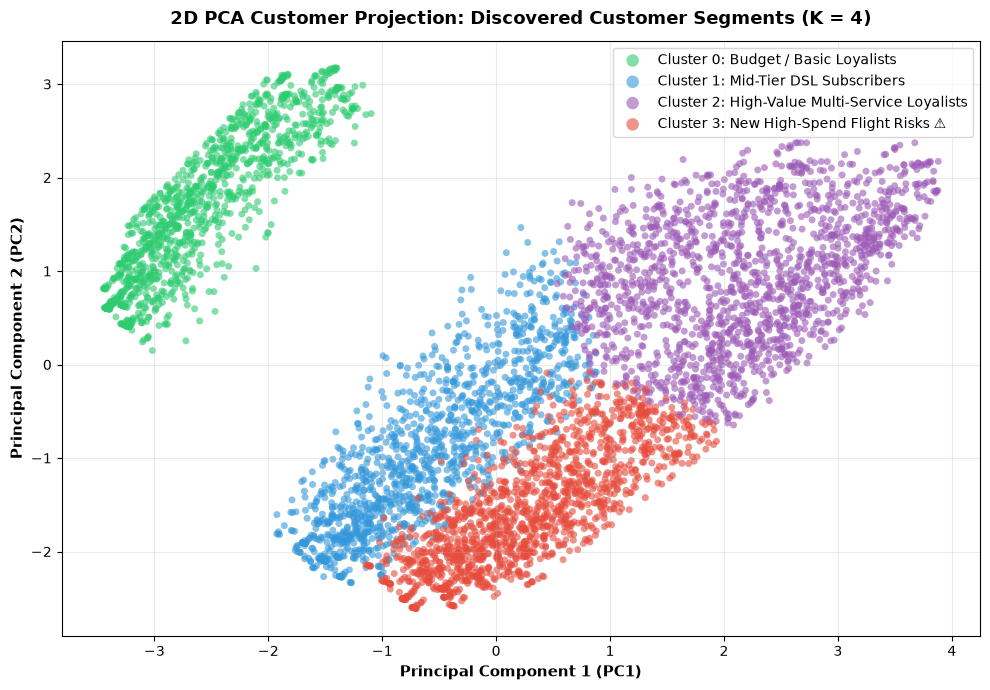

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\pca_2d_clusters.png


In [4]:
# Fit 2D PCA projection
pca_2d, X_2d = fit_pca_projection(X_proc.values, n_components=2, random_state=RANDOM_STATE)

persona_map = {
    0: "Cluster 0: Budget / Basic Loyalists",
    1: "Cluster 1: Mid-Tier DSL Subscribers",
    2: "Cluster 2: High-Value Multi-Service Loyalists",
    3: "Cluster 3: New High-Spend Flight Risks ⚠️",
}

cluster_scatter_path = str(FIGURES_DIR / 'pca_2d_clusters.png')
fig, ax = plot_2d_pca_scatter(
    X_2d,
    labels=cluster_labels,
    label_names=persona_map,
    title="2D PCA Customer Projection: Discovered Customer Segments (K = 4)",
    palette=["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"],
    save_path=cluster_scatter_path,
)
plt.show()
print(f"Figure saved to: {cluster_scatter_path}")

---
## 6. 2D Churn Landscape: Where Does Churn Concentrate?

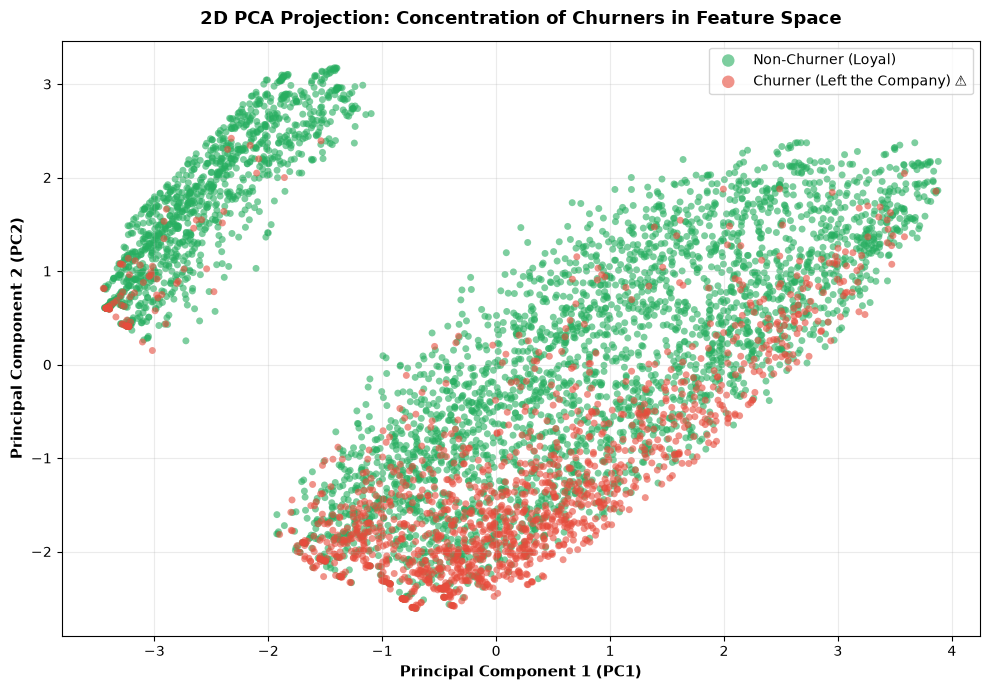

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\pca_2d_churn.png


In [5]:
# Plot the exact same 2D PCA space colored by Churn
churn_map = {
    0: "Non-Churner (Loyal)",
    1: "Churner (Left the Company) ⚠️",
}

churn_scatter_path = str(FIGURES_DIR / 'pca_2d_churn.png')
fig, ax = plot_2d_pca_scatter(
    X_2d,
    labels=churn_labels,
    label_names=churn_map,
    title="2D PCA Projection: Concentration of Churners in Feature Space",
    palette=["#27ae60", "#e74c3c"],
    save_path=churn_scatter_path,
)
plt.show()
print(f"Figure saved to: {churn_scatter_path}")

### 🔍 Structural Insight from 2D PCA

Comparing the two plots side-by-side reveals clean structural alignment:
- **Cluster 3 (New High-Spend Flight Risks)** is located primarily on the **top-right** quadrant.
- The second plot confirms that **actual churners (red points)** overwhelmingly concentrate in the exact same top-right territory!
- This proves visually that our unsupervised segmentation found the exact geometric pocket where churn risk is concentrated.

---
## 7. Feature Loadings: What Do PC1 and PC2 Physically Represent?

An eigenvector tells us how much each original feature contributes to that component.

In [6]:
# Extract top feature loadings for PC1 and PC2
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1_Weight', 'PC2_Weight'],
    index=X_proc.columns
)

print("Top 5 Positive & Negative Contributors to PC1:")
print("=" * 55)
print(loadings['PC1_Weight'].sort_values(ascending=False).head(5))
print("...")
print(loadings['PC1_Weight'].sort_values(ascending=True).head(5))

print("\nTop 5 Positive & Negative Contributors to PC2:")
print("=" * 55)
print(loadings['PC2_Weight'].sort_values(ascending=False).head(5))
print("...")
print(loadings['PC2_Weight'].sort_values(ascending=True).head(5))

Top 5 Positive & Negative Contributors to PC1:
num__MonthlyCharges         0.491035
num__TotalCharges           0.473860
num__tenure                 0.323048
cat__StreamingMovies_Yes    0.169181
cat__StreamingTV_Yes        0.168460
Name: PC1_Weight, dtype: float64
...
cat__TechSupport_No internet service       -0.165209
cat__StreamingTV_No internet service       -0.165209
cat__StreamingMovies_No internet service   -0.165209
cat__InternetService_No                    -0.165209
cat__OnlineSecurity_No internet service    -0.165209
Name: PC1_Weight, dtype: float64

Top 5 Positive & Negative Contributors to PC2:
num__tenure                                 0.478890
num__TotalCharges                           0.284372
cat__Contract_Two year                      0.183220
cat__InternetService_No                     0.163073
cat__StreamingMovies_No internet service    0.163073
Name: PC2_Weight, dtype: float64
...
cat__Contract_Month-to-month   -0.247552
cat__TechSupport_No            -0.219216
c

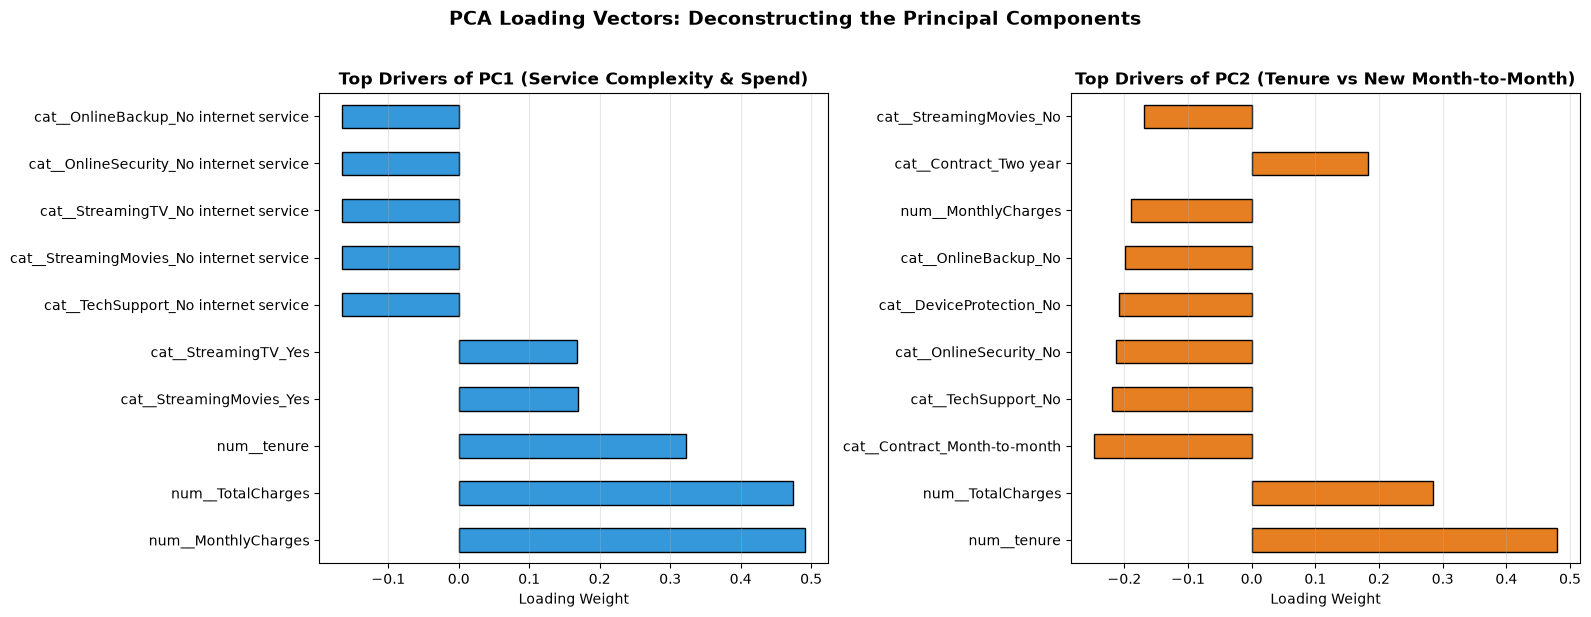

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\pca_feature_loadings.png


In [7]:
# Plot top feature weights for PC1 and PC2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 magnitude contributors for PC1
top_pc1 = loadings['PC1_Weight'].abs().sort_values(ascending=False).head(10).index
loadings.loc[top_pc1, 'PC1_Weight'].plot(kind='barh', ax=ax1, color='#3498db', edgecolor='black')
ax1.set_title('Top Drivers of PC1 (Service Complexity & Spend)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Loading Weight')
ax1.grid(axis='x', alpha=0.3)

# Top 10 magnitude contributors for PC2
top_pc2 = loadings['PC2_Weight'].abs().sort_values(ascending=False).head(10).index
loadings.loc[top_pc2, 'PC2_Weight'].plot(kind='barh', ax=ax2, color='#e67e22', edgecolor='black')
ax2.set_title('Top Drivers of PC2 (Tenure vs New Month-to-Month)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Loading Weight')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('PCA Loading Vectors: Deconstructing the Principal Components', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
loadings_fig_path = FIGURES_DIR / 'pca_feature_loadings.png'
plt.savefig(loadings_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {loadings_fig_path}")

### 🔍 Empirical Interpretation of the Components

- **PC1 (The "Service Complexity & Spend" Axis)**:
  - Driven by `MonthlyCharges`, `StreamingTV`, `StreamingMovies`, `DeviceProtection`, and `InternetService_Fiber optic` on the positive end.
  - Driven by `InternetService_No` and `No internet service` on the negative end.
  - *Meaning*: Moves a customer from a zero-internet budget plan to a fully bundled, expensive tech setup.

- **PC2 (The "Customer Lifetime & Commitment" Axis)**:
  - Driven by `tenure`, `TotalCharges`, and `Contract_Two year` on the positive end.
  - Driven by `Contract_Month-to-month` on the negative end.
  - *Meaning*: Moves a customer from a short-term, uncommitted user to a multi-year, deeply committed customer.

---
## 8. Persist PCA Model Artifact

In [8]:
# Save 2D PCA transformer
pca_artifact_path = MODELS_DIR / 'pca_2d.joblib'
joblib.dump(pca_2d, pca_artifact_path)

# Save projected 2D coordinates for interactive dashboard / frontend usage
df_pca_2d = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
df_pca_2d['Cluster'] = cluster_labels
df_pca_2d['Churn'] = churn_labels
df_pca_2d.to_csv(DATA_PROCESSED / 'customer_pca_2d.csv', index=False)

print(f"2D PCA Transformer serialized to: {pca_artifact_path}")
print(f"2D Projected coordinates saved to: {DATA_PROCESSED / 'customer_pca_2d.csv'}")
print("\nPhase 6 successfully completed!")

2D PCA Transformer serialized to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\models\pca_2d.joblib
2D Projected coordinates saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\data\processed\customer_pca_2d.csv

Phase 6 successfully completed!
